<a href="https://colab.research.google.com/github/julestek/nlp-ticket-classification/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import userdata

!mkdir -p ~/.kaggle
token = userdata.get('KAGGLE_TOKEN')
with open('/root/.kaggle/access_token', 'w') as f:
    f.write(token)
!chmod 600 ~/.kaggle/access_token

!pip install -q kaggle

!kaggle datasets download -d adisongoh/it-service-ticket-classification-dataset -p data/raw --unzip

Dataset URL: https://www.kaggle.com/datasets/adisongoh/it-service-ticket-classification-dataset
License(s): CC0-1.0
100% 3.45M/3.45M [00:00<00:00, 129MB/s]



In [3]:
import os
print(os.listdir("data/raw"))

['all_tickets_processed_improved_v3.csv']


In [4]:
import pandas as pd

df = pd.read_csv("data/raw/all_tickets_processed_improved_v3.csv")  # remplace par le vrai nom vu ci-dessus

print(f"Shape: {df.shape}")
df.head()

Shape: (47837, 2)


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

Topic_group
Hardware                 28.465414
HR Support               22.817066
Access                   14.894329
Miscellaneous            14.758451
Storage                   5.805130
Purchase                  5.150825
Internal Project          4.429626
Administrative rights     3.679160
Name: proportion, dtype: float64


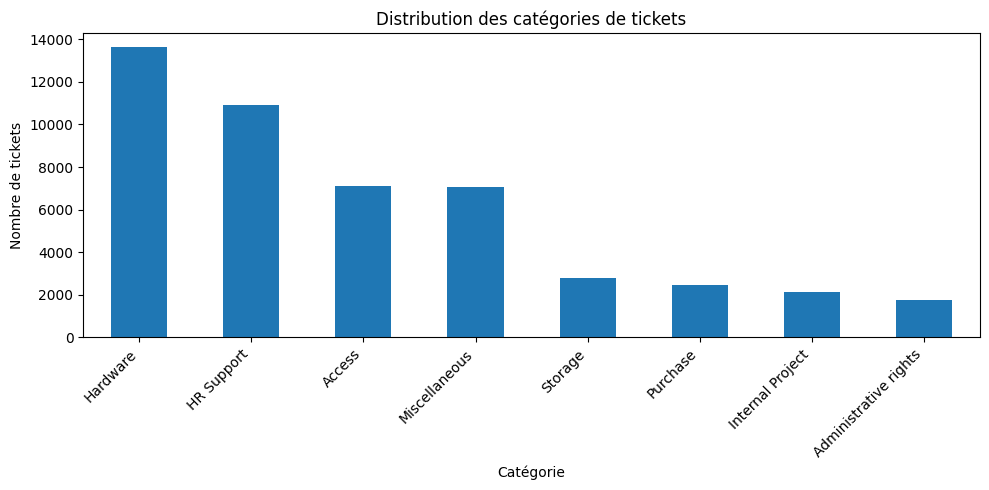

In [5]:
import matplotlib.pyplot as plt

# Comptage brut
print(df['Topic_group'].value_counts())
print()
# En pourcentage, plus parlant pour évaluer le déséquilibre
print(df['Topic_group'].value_counts(normalize=True) * 100)

# Visualisation
plt.figure(figsize=(10, 5))
df['Topic_group'].value_counts().plot(kind='bar')
plt.title("Distribution des catégories de tickets")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de tickets")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# On mesure en mots (approximation simple avant la vraie tokenization BERT)
df['n_words'] = df['Document'].apply(lambda x: len(str(x).split()))

print(df['n_words'].describe())
print()
print(f"Médiane: {df['n_words'].median()}")
print(f"95e percentile: {df['n_words'].quantile(0.95)}")
print(f"99e percentile: {df['n_words'].quantile(0.99)}")
print(f"Max: {df['n_words'].max()}")

count    47837.000000
mean        43.597341
std         56.736800
min          2.000000
25%         17.000000
50%         26.000000
75%         46.000000
max        981.000000
Name: n_words, dtype: float64

Médiane: 26.0
95e percentile: 136.0
99e percentile: 284.0
Max: 981


In [8]:
# Les 5 tickets les plus longs
longest = df.nlargest(5, 'n_words')
for idx, row in longest.iterrows():
    print(f"--- {row['n_words']} mots — catégorie: {row['Topic_group']} ---")
    print(row['Document'][:300])  # les 300 premiers caractères seulement
    print()

--- 981 mots — catégorie: Administrative rights ---
complete tab re complete tab please hi ll have look come back you please log ticket for assign thank you best regards administrator sent monday july fwd complete tab please hi can someone please check out access unable amend tab regards change control one canada square canary wharf change control fo

--- 953 mots — catégorie: Miscellaneous ---
signed signed hello please log assign best regards senior engineer wednesday pm signed hi please example convinced problem where things updated then regress seen multiple times opportunities which close dates future which then revert close dates past more serious trail destroyed signed contracts sig

--- 934 mots — catégorie: Access ---
service user periodic lockout problem sent friday october periodic lockout problem hi could you raise ticket ask look into problem noted by thread below seems ad called getting locked out every often causing authentication failures but think able determine why ge

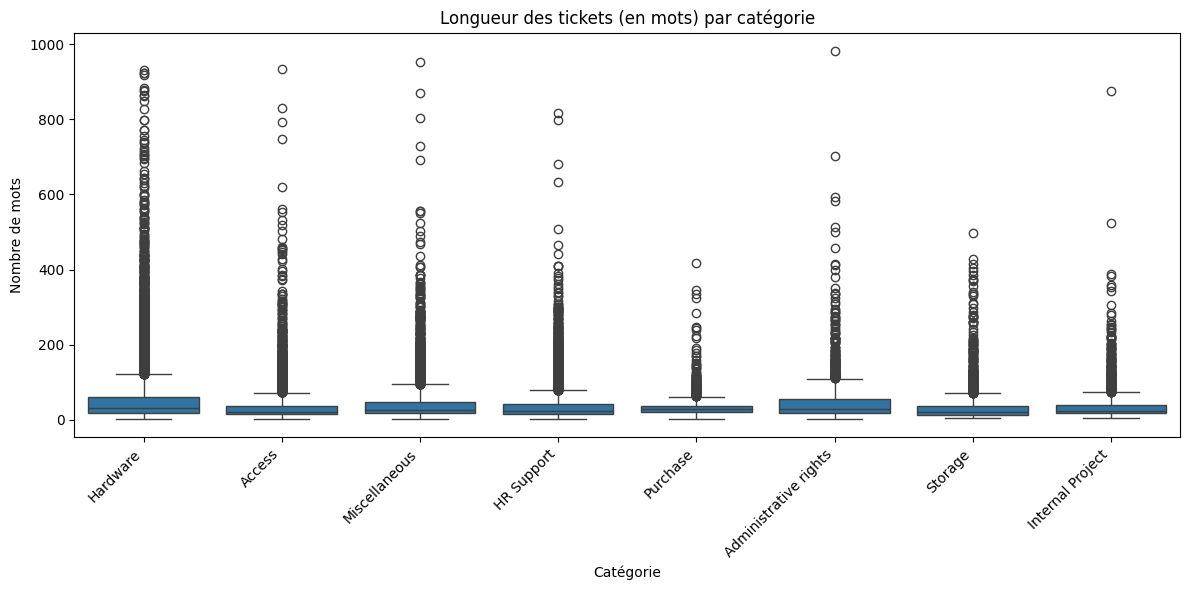

                            mean   50%        std
Topic_group                                      
Access                 35.600000  22.0  47.191681
Administrative rights  50.361932  30.0  63.853702
HR Support             37.766651  24.0  42.286225
Hardware               56.273041  32.0  75.520222
Internal Project       37.706937  24.0  44.553206
Miscellaneous          42.953966  27.0  52.186345
Purchase               34.932630  30.0  25.866869
Storage                34.409795  21.0  42.904582


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Topic_group', y='n_words')
plt.xticks(rotation=45, ha='right')
plt.title("Longueur des tickets (en mots) par catégorie")
plt.ylabel("Nombre de mots")
plt.xlabel("Catégorie")
plt.tight_layout()
plt.show()

# Version chiffrée, plus facile à lire que le graphique seul
print(df.groupby('Topic_group')['n_words'].describe()[['mean', '50%', 'std']])

In [10]:
from collections import Counter

def top_words_by_category(df, category, n=15):
    texts = df[df['Topic_group'] == category]['Document']
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

for cat in df['Topic_group'].unique():
    print(f"--- {cat} ---")
    print(top_words_by_category(df, cat))
    print()

--- Hardware ---
[('please', 19401), ('you', 10095), ('hi', 9143), ('regards', 9038), ('for', 8909), ('re', 8778), ('pm', 7903), ('hello', 7666), ('thank', 7551), ('sent', 6741), ('thanks', 6067), ('with', 5440), ('access', 4773), ('have', 4570), ('can', 4490)]

--- Access ---
[('please', 9006), ('confluence', 4587), ('pm', 4401), ('hi', 4001), ('regards', 3440), ('hello', 3182), ('thanks', 3150), ('thank', 3097), ('card', 2656), ('user', 2654), ('access', 2643), ('re', 2508), ('for', 2480), ('password', 2190), ('license', 1880)]

--- Miscellaneous ---
[('please', 11258), ('hi', 4660), ('pm', 4605), ('change', 4390), ('for', 4354), ('regards', 4116), ('thank', 3866), ('hello', 3405), ('thanks', 3264), ('add', 3197), ('you', 2982), ('re', 2780), ('name', 2493), ('sent', 2297), ('kind', 1920)]

--- HR Support ---
[('please', 16289), ('pm', 6477), ('thank', 6192), ('hi', 6092), ('for', 5950), ('leaver', 5646), ('regards', 5386), ('hello', 5383), ('error', 4778), ('form', 4570), ('starter'

In [11]:
# Doublons
n_duplicates = df['Document'].duplicated().sum()
print(f"Textes dupliqués : {n_duplicates} ({n_duplicates/len(df)*100:.2f}%)")

# Valeurs manquantes / textes très courts (potentiellement vides de sens)
print(f"Valeurs manquantes : {df['Document'].isna().sum()}")
print(f"Textes de moins de 3 mots : {(df['n_words'] < 3).sum()}")

Textes dupliqués : 0 (0.00%)
Valeurs manquantes : 0
Textes de moins de 3 mots : 14


In [12]:
df[df['n_words'] < 3][['Document', 'Topic_group']]

,Document,Topic_group
4215,open si,Hardware
4635,account developer,Access
6450,possible possible,HR Support
8799,cont care,Hardware
10596,leaver leaver,HR Support
11612,relocate relocate,Hardware
15528,enable enable,HR Support
22172,timecards timecards,HR Support
23348,cable tester,Hardware
29681,installation officer,Purchase


## Résumé de l'EDA

**Dataset** : 47 837 tickets IT, 8 catégories, aucun doublon ni valeur manquante.

**Déséquilibre des classes** : ratio 7.7x entre la classe majoritaire (Hardware, 28.5%)
et minoritaire (Administrative rights, 3.7%). → Métrique retenue : F1-macro.
Split train/val/test stratifié. On comparera avec/sans pondération de classes (class_weight).

**Longueur des textes** : distribution très asymétrique (médiane 26 mots,
99e percentile 284 mots, max 981 mots). Les textes longs sont des threads email
complets, pas des anomalies à exclure. → max_length=256 pour le tokenizer,
troncature automatique acceptée et documentée comme limite.

**Qualité du texte** : dataset déjà préprocessé en amont par l'auteur Kaggle
(lowercase, ponctuation supprimée). → Limite documentée : impact négatif attendu
sur les performances de DistilBERT, qui exploite normalement casse et ponctuation.

**Vocabulaire** : bon pouvoir discriminant par catégorie malgré le bruit des
formules de politesse (please, hi, regards...). Miscellaneous a un vocabulaire
plus générique → catégorie probablement la plus difficile à classifier,
à surveiller en analyse d'erreurs.